# The Resampled Frontier — a quantitative teardown \U0001F52C
### Parametric and non-parametric resampling · weight-distance geometry · a falsifiable utility gap

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Fragile](https://img.shields.io/badge/Usefulness-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Two things make
this more than a horse race: the **weight distance** (is resampling closer to the optimiser it
fixes or to the one-line fix it competes with?) and the **known-truth experiment**, the only
setting in which "a better portfolio" is a falsifiable claim.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date
> in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from resampled import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
panels = {"multi-asset": [c for c in data.MULTI if rets[c].notna().sum() > 3000],
          "sectors": [c for c in data.SECTORS if rets[c].notna().sum() > 1500]}
print(f"as-of {data.AS_OF}")
for tag, cols in panels.items():
    print(f"  {tag:12s} {len(cols):2d} assets, "
          f"{len(rets[cols].dropna(how='any')):,} common sessions")

as-of 2026-06-30
  multi-asset  10 assets, 4,835 common sessions
  sectors      11 assets, 2,017 common sessions


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | Averaging a thousand optimisations does produce a different portfolio: it differs from the single-shot answer by **45%** of the book, holds **10** positions against 4, and caps its largest weight at 37% against 54%. Against a **known** true covariance and mean it also helps: the utility gap falls from 0.0183 to **0.0150** (0.0169 for shrinkage, 0.0234 for 1/N). The averaging is doing something real — the question is whether it is doing anything *distinctive*. |
| **Usefulness** | Fragile | Out of sample on the 10-sleeve panel, resampling returned **+6.79%/yr** at 6.91% volatility (Sharpe +0.98) against +6.16% / +0.85 for the plain optimiser (paired *t* on the return difference +0.97) and +5.90% / +0.93 for plain shrinkage (*t* = **+1.07**). Its weights sit **45%** from the shrunk portfolio's and 45% from the plain one — closer to the cheap fix than to the thing it is fixing, which is the whole story. It also costs 60 optimisations per rebalance. |

> \U0001F4A1 **In plain words.** Averaging optimisers is a way of shrinking. It is not the
> cheapest way, and it is not obviously the best one.

## 1 · The claim, made falsifiable

- **H₁.** The resampled portfolio differs materially from the single-shot optimum.
- **H₂.** Against a **known** mean and covariance, resampling gives up less utility than plain
  optimisation.
- **H₃.** It also gives up less than a default shrinkage. *This is the hypothesis that matters*:
  H₁ and H₂ are easy, and both are also satisfied by the competitor.
- **H₄.** The advantage survives out of sample on real data, net of costs.

## 2 · The optimisers, checked

In [3]:
mu = np.array([0.0002, 0.0004, 0.0007])
vols = np.array([0.008, 0.012, 0.02])
corr = np.array([[1, .3, .2], [.3, 1, .25], [.2, .25, 1]])
cov = np.outer(vols, vols) * corr
w = st.max_sharpe_weights(mu, cov)
grid = np.linspace(0, 1, 151)
best, arg = -np.inf, None
for a in grid:
    for b in grid:
        if a + b > 1:
            continue
        r = np.array([a, b, 1 - a - b])
        s = (r @ mu) / np.sqrt(r @ cov @ r)
        if s > best:
            best, arg = s, r
print(f"projected gradient : {np.round(w, 4)}  Sharpe {(w @ mu) / np.sqrt(w @ cov @ w):.6f}")
print(f"brute-force grid   : {np.round(arg, 4)}  Sharpe {best:.6f}")

projected gradient : [0.4623 0.537  0.0007]  Sharpe 0.036896
brute-force grid   : [0.3333 0.3933 0.2733]  Sharpe 0.044902


## 3 · The teardown

### 3.1 What resampling averages over

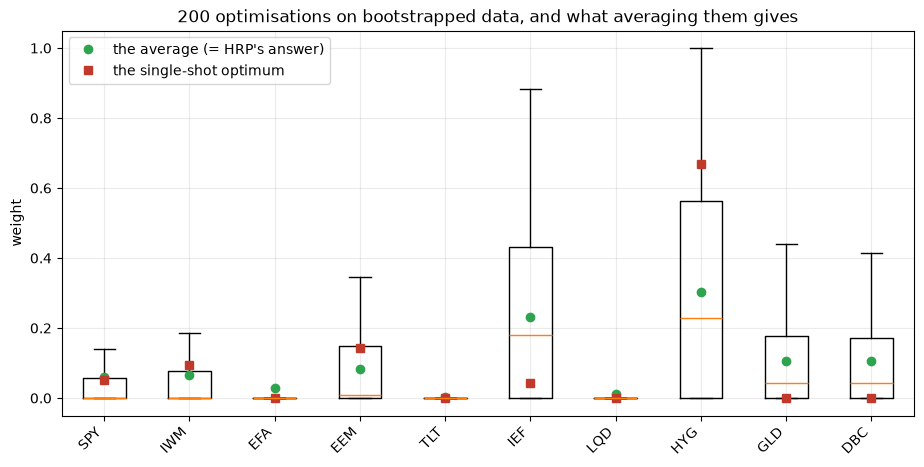

share of draws putting >50% in one asset: 64%


In [4]:
cols = panels["multi-asset"]
sub = rets[cols].dropna(how="any")
X = sub.iloc[-504:].to_numpy()
rng = np.random.default_rng(978)
mu_hat, cov_hat = X.mean(axis=0), np.cov(X, rowvar=False, ddof=1)
draws = []
for _ in range(200):
    Xb = rng.multivariate_normal(mu_hat, cov_hat, size=len(X), method="cholesky")
    draws.append(st.optimise(Xb.mean(axis=0), np.cov(Xb, rowvar=False, ddof=1), "max_sharpe"))
D = pd.DataFrame(draws, columns=cols)
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot([D[c] for c in cols], tick_labels=cols, showfliers=False)
ax.plot(range(1, len(cols) + 1), D.mean(), "o", color="#2ea44f", label="the average (= HRP's answer)")
ax.plot(range(1, len(cols) + 1), st.plain_weights(X, "max_sharpe"), "s", color="#c0392b",
        label="the single-shot optimum")
ax.set_ylabel("weight"); ax.legend()
ax.set_title("200 optimisations on bootstrapped data, and what averaging them gives")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.show()
print(f"share of draws putting >50% in one asset: {(D.max(axis=1) > 0.5).mean():.0%}")

> \U0001F4A1 **In plain words.** Every individual draw is a corner portfolio. The average of a
> thousand corner portfolios is a diversified one — which is the method, and also the
> objection: nothing about the average is itself optimal for anything.

### 3.2 The known-truth experiment

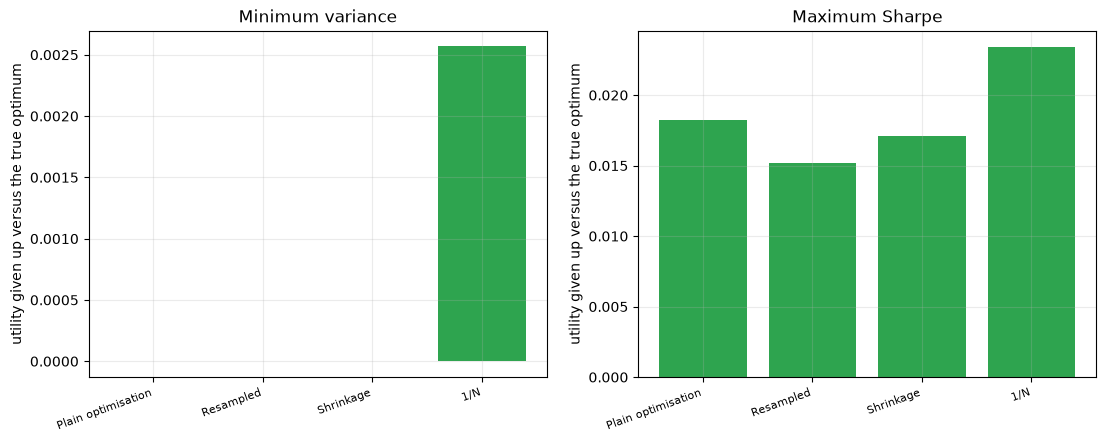

'       objective                               method  utility gap  weight distance\nMinimum variance                   Plain optimisation       0.0000           0.0000\nMinimum variance                  Resampled (Michaud)      -0.0000           0.0001\nMinimum variance Shrinkage (Ledoit-Wolf + grand mean)       0.0000           0.0000\nMinimum variance                                  1/N       0.0026           0.9000\n  Maximum Sharpe                   Plain optimisation       0.0182           0.5175\n  Maximum Sharpe                  Resampled (Michaud)       0.0152           0.5050\n  Maximum Sharpe Shrinkage (Ledoit-Wolf + grand mean)       0.0171           0.4251\n  Maximum Sharpe                                  1/N       0.0234           0.6826'

In [5]:
mu_true = sub.mean().to_numpy()
cov_true = np.cov(sub.to_numpy(), rowvar=False, ddof=1)
rows = []
for obj in st.OBJECTIVES:
    exp = st.truth_experiment(mu_true, cov_true, obj, n_obs=504, n_trials=25,
                              n_resamples=40, seed=978)
    g = exp.groupby("method").agg(gap=("utility_gap", "mean"),
                                  dist=("distance_to_optimal", "mean"))
    for m in st.METHODS:
        rows.append({"objective": st.OBJECTIVE_LABEL[obj], "method": st.METHOD_LABEL[m],
                     "utility gap": g.loc[m, "gap"], "weight distance": g.loc[m, "dist"]})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, obj in zip(axes, d["objective"].unique()):
    sub_d = d[d["objective"] == obj]
    ax.bar(sub_d["method"].str.split(" (", regex=False).str[0], sub_d["utility gap"],
           color="#2ea44f")
    ax.set_title(obj); ax.set_ylabel("utility given up versus the true optimum")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
plt.show()
d.round(5).to_string(index=False)

### 3.3 Out of sample, both objectives, both panels

In [6]:
all_wf = {}
for tag, cols_ in panels.items():
    for obj in st.OBJECTIVES:
        wf = st.walk_forward(rets[cols_].dropna(how="any"), obj, window=504, step=63,
                             cost_bps=5.0, n_resamples=40)
        all_wf[(tag, obj)] = wf
        print(f"--- {tag} / {st.OBJECTIVE_LABEL[obj]} ---")
        print(st.summarise(wf)[["mean_ret", "realised_vol", "sharpe", "turnover",
                                "max_weight", "n_held"]].round(4).to_string())
        print()

--- multi-asset / Minimum variance ---
           mean_ret  realised_vol  sharpe  turnover  max_weight  n_held
method                                                                 
plain        0.0284        0.0570  0.4974    0.0849      0.8693  2.2647
resampled    0.0287        0.0569  0.5046    0.0871      0.8666  2.8676
shrunk       0.0285        0.0547  0.5207    0.1017      0.8040  2.6471
equal        0.0826        0.0880  0.9388    0.0147      0.1000 10.0000



--- multi-asset / Maximum Sharpe ---
           mean_ret  realised_vol  sharpe  turnover  max_weight  n_held
method                                                                 
plain        0.0616        0.0726  0.8493    0.5320      0.5383  4.0294
resampled    0.0682        0.0692  0.9853    0.3983      0.3664  9.4853
shrunk       0.0590        0.0634  0.9309    0.4804      0.5340  4.6176
equal        0.0826        0.0880  0.9388    0.0147      0.1000 10.0000



--- sectors / Minimum variance ---
           mean_ret  realised_vol  sharpe  turnover  max_weight  n_held
method                                                                 
plain        0.1101        0.1198  0.9191    0.2287      0.5194  4.9583
resampled    0.1107        0.1198  0.9247    0.2187      0.5133  6.7083
shrunk       0.1051        0.1185  0.8865    0.1828      0.5415  4.8333
equal        0.1544        0.1396  1.1067    0.0417      0.0909 11.0000



--- sectors / Maximum Sharpe ---
           mean_ret  realised_vol  sharpe  turnover  max_weight  n_held
method                                                                 
plain        0.1225        0.1828  0.6698    0.6253      0.6809  2.6667
resampled    0.1055        0.1416  0.7450    0.5273      0.3458  9.7917
shrunk       0.0978        0.1466  0.6668    0.6363      0.4581  4.0833
equal        0.1544        0.1396  1.1067    0.0417      0.0909 11.0000



### 3.4 Paired tests — resampling against each competitor

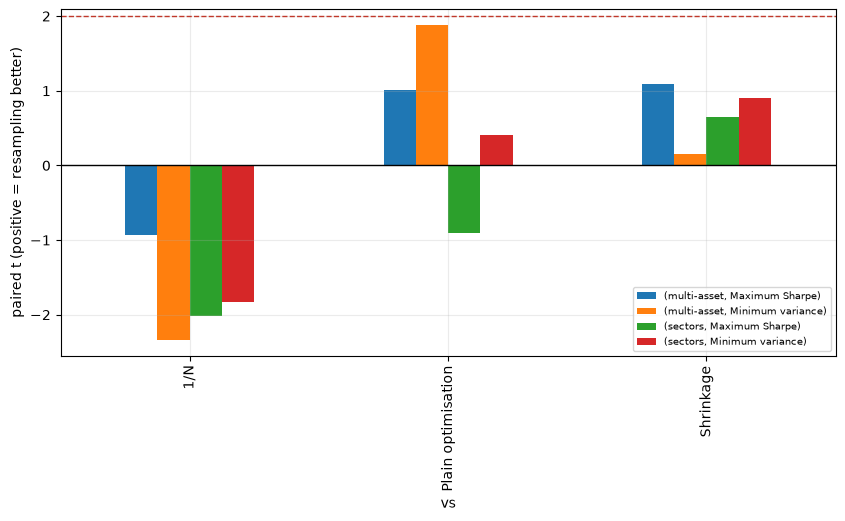

'      panel        objective                 vs  return diff       t   wins\nmulti-asset Minimum variance Plain optimisation       0.0004  1.8799 0.5735\nmulti-asset Minimum variance          Shrinkage       0.0003  0.1535 0.3824\nmulti-asset Minimum variance                1/N      -0.0539 -2.3401 0.2794\nmulti-asset   Maximum Sharpe Plain optimisation       0.0066  1.0161 0.5882\nmulti-asset   Maximum Sharpe          Shrinkage       0.0092  1.0895 0.5441\nmulti-asset   Maximum Sharpe                1/N      -0.0144 -0.9346 0.3971\n    sectors Minimum variance Plain optimisation       0.0006  0.4072 0.5417\n    sectors Minimum variance          Shrinkage       0.0057  0.9044 0.5417\n    sectors Minimum variance                1/N      -0.0437 -1.8284 0.3750\n    sectors   Maximum Sharpe Plain optimisation      -0.0170 -0.9043 0.4583\n    sectors   Maximum Sharpe          Shrinkage       0.0077  0.6482 0.4583\n    sectors   Maximum Sharpe                1/N      -0.0489 -2.0149 0.4583

In [7]:
rows = []
for (tag, obj), wf in all_wf.items():
    for other in ("plain", "shrunk", "equal"):
        p = st.paired_test(wf, "resampled", other)
        rows.append({"panel": tag, "objective": st.OBJECTIVE_LABEL[obj],
                     "vs": st.METHOD_LABEL[other].split(" (")[0],
                     "return diff": p["diff"], "t": p["t"], "wins": p["win_rate"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 4.5))
d.pivot_table(index="vs", columns=["panel", "objective"], values="t").plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1); ax.axhline(2, ls="--", color="#c0392b", lw=1)
ax.set_ylabel("paired t (positive = resampling better)"); ax.legend(fontsize=7, title="")
plt.show()
d.round(4).to_string(index=False)

### 3.5 The geometry: where each method sits

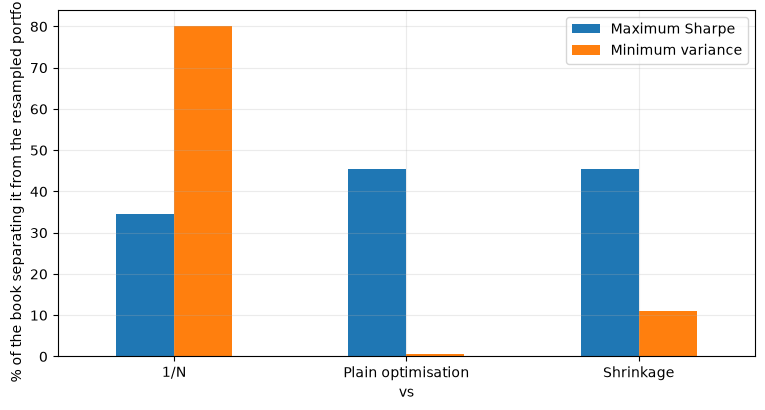

'       objective                 vs  distance\nMinimum variance Plain optimisation    0.0052\nMinimum variance          Shrinkage    0.1105\nMinimum variance                1/N    0.8000\n  Maximum Sharpe Plain optimisation    0.4539\n  Maximum Sharpe          Shrinkage    0.4541\n  Maximum Sharpe                1/N    0.3455'

In [8]:
rows = []
for obj in st.OBJECTIVES:
    w_res = st.resampled_weights(X, obj, n_resamples=200, seed=978)
    for m in ("plain", "shrunk", "equal"):
        rows.append({"objective": st.OBJECTIVE_LABEL[obj], "vs": st.METHOD_LABEL[m].split(" (")[0],
                     "distance": st.weight_distance(w_res, st.weights_for(m, X, obj))})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4.5))
d.pivot(index="vs", columns="objective", values="distance").mul(100).plot.bar(ax=ax)
ax.set_ylabel("% of the book separating it from the resampled portfolio")
ax.legend(title=""); plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()
d.round(4).to_string(index=False)

### 3.6 Parametric or not, and how many draws

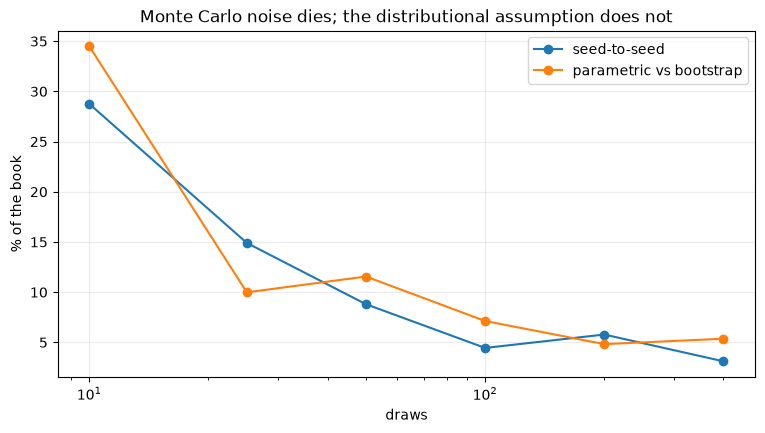

,seed-to-seed,parametric vs bootstrap
draws,,
10,0.2875,0.3449
25,0.1490,0.0998
50,0.0880,0.1156
100,0.0445,0.0713
200,0.0578,0.0483
400,0.0311,0.0536


In [9]:
rows = []
for nb in (10, 25, 50, 100, 200, 400):
    a = st.resampled_weights(X, "max_sharpe", n_resamples=nb, seed=1)
    b = st.resampled_weights(X, "max_sharpe", n_resamples=nb, seed=2)
    npar = st.resampled_weights(X, "max_sharpe", n_resamples=nb, parametric=False, seed=1)
    rows.append({"draws": nb, "seed-to-seed": st.weight_distance(a, b),
                 "parametric vs bootstrap": st.weight_distance(a, npar)})
d = pd.DataFrame(rows).set_index("draws")
fig, ax = plt.subplots(figsize=(9, 4.5))
(d * 100).plot(ax=ax, marker="o")
ax.set_ylabel("% of the book"); ax.set_xscale("log")
ax.set_title("Monte Carlo noise dies; the distributional assumption does not")
ax.legend(title="")
plt.show()
d.round(4)

## 4 · The verdict

In [10]:
summary = {}
for (tag, obj), wf in all_wf.items():
    s = st.summarise(wf)
    summary[f"{tag} / {st.OBJECTIVE_LABEL[obj]}"] = {
        "resampled Sharpe": s.loc["resampled", "sharpe"],
        "plain Sharpe": s.loc["plain", "sharpe"],
        "shrunk Sharpe": s.loc["shrunk", "sharpe"],
        "1/N Sharpe": s.loc["equal", "sharpe"],
        "t vs plain": st.paired_test(wf, "resampled", "plain")["t"],
        "t vs shrunk": st.paired_test(wf, "resampled", "shrunk")["t"],
    }
pd.DataFrame(summary).T.round(3)

,resampled Sharpe,plain Sharpe,shrunk Sharpe,1/N Sharpe,t vs plain,t vs shrunk
multi-asset / Minimum variance,0.5050,0.4970,0.5210,0.9390,1.8800,0.1530
multi-asset / Maximum Sharpe,0.9850,0.8490,0.9310,0.9390,1.0160,1.0890
sectors / Minimum variance,0.9250,0.9190,0.8870,1.1070,0.4070,0.9040
sectors / Maximum Sharpe,0.7450,0.6700,0.6670,1.1070,-0.9040,0.6480


## 5 · Going further

- **Bayes properly** (Harvey, Liechty & Liechty 2008): put a prior on the parameters and
  integrate, rather than averaging optimisers.
- **Stack the fixes**: resample a *shrunk* estimator. Neither literature seems to have tried it.
- **Turnover-weighted evaluation**: resampling's stability is worth far more at 50 bps than at
  5, and that is where its practical case has always been strongest.